# Análise de Séries Temporais

### Componentes essencias de Séries Temporais

- Tendência: é uma maneira de analisar uma variação do nível médio ao longo do tempo, desta forma não é possível calcular a média da série temporal, uma vez que ela torna-se móvel

- Sazonalidade: é uma maneira de analisar ao longo do período do ano algum fenômeno, por exemplo: gripe causada por Influenza (mais comum no inverno)

- Tendência + Sazonalidade: 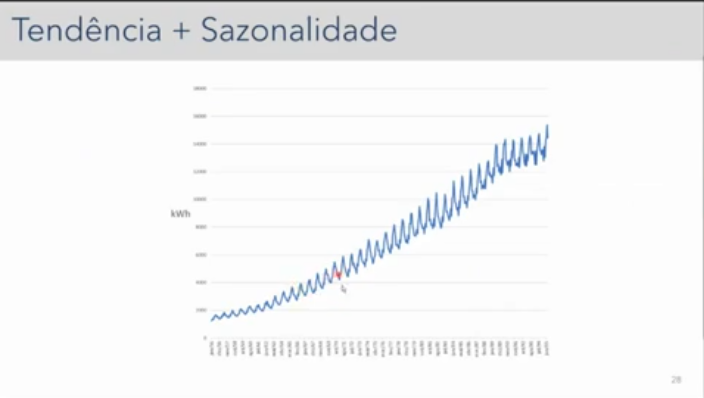

- Ruído ou Componente Estocástico?

- Ciclos: Trata-se de ciclos longos que não enquadram-se na periodicidade anual


### Estacionaridade

Conceito: uma série temporal é estacionária se suas propriedades estatísticas não mudam com o tempo

Características: 
- Média deve manter-se constante
- Variância também
- Autocovariância deve ser a mesma para dois intervalos de tempo em que possuem a mesma distância, ou seja a autocovariância entre $\text{X10}$ e $\text{X15}$ deve ser a mesma que $\text{X100}$ e $\text{X105}$, podendo ser avaliado uma vez que o intervalo possui o mesmo $\text{Lag}$

**Sempre que houver uma série com Tendência ou Sazonalidade, jamais será estacionária**

Para esse caso, a covariância, média e variância deve ser a mesma para ser estacionária
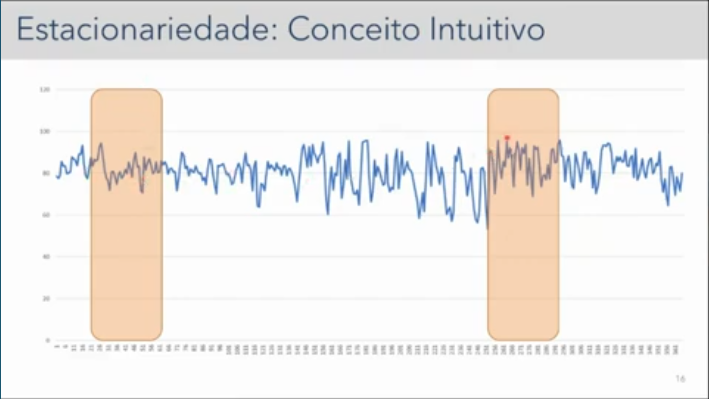

Para esse caso, apenas a média e variância deve ser a mesma para ser estacionária, porém não seria a mesma covariância, uma vez que não teremos a mesma distribuição para janelas com intervalos distintos
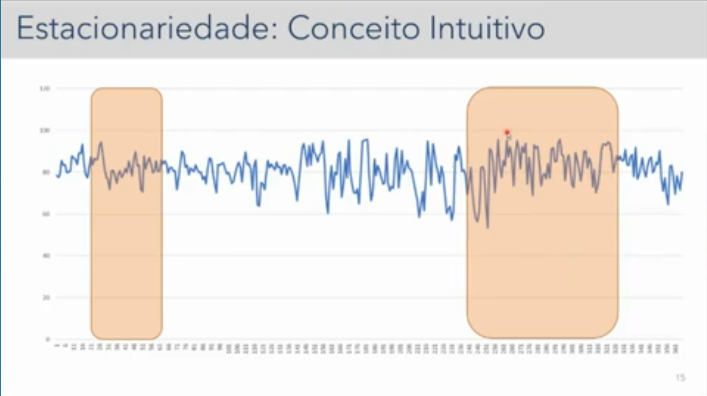

Neste caso, não será estacionária, uma vez que a média não é constante ao longo do tempo, assim:
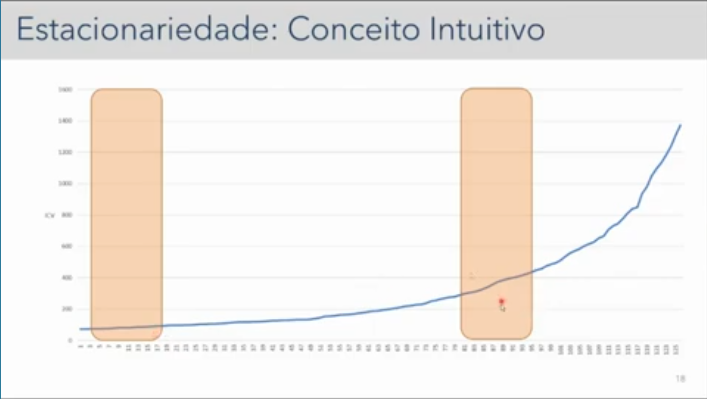




Uma série temporal pode ser não estacionária em ao longo de todo seu período, porém em um intervalo pode ser estacionária

Caso os dados não sejam estacionário, podemos transformar os dados originais, como realizar uma derivada para manter uma estacionaridade


### Processos Estocásticos

Conceito: é uma família de variáveis aleatórias, indexadas pelo parâmetro $\text{t}$, consideraremos que o parâmetro é o tempo

- Discreto: Quando $\text{T}$ é contável
- Contínuo: Quando $\text{T}$ é incontável

Espaço dos Estados:
- É o conjunto de todos os valores possíveis que as Variáveis Aleatórias podem assumir 

### Autocorrelação

- Para provarmos que a série temporal não é estacionária, assumiremos que a autocorrelação é estacionária, ou seja é descrita por um vetor de autocorrelação e após isso provaremos que não é possível descrever como um vetor e sim uma matriz a autocorrelação

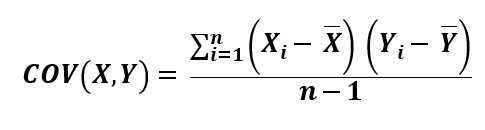
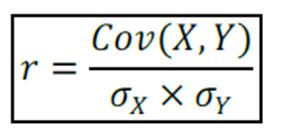

- Um sinal para analisar se uma série é estacionário, caso a autocorrelação caia de maneira 'abrupta', é um indicativo de estacionariedade

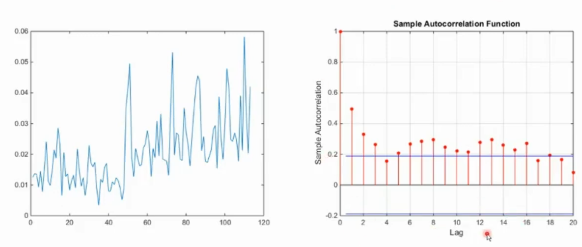

- Neste caso, a autocorrelação não decaiu próxima a zero, então não é estacionária

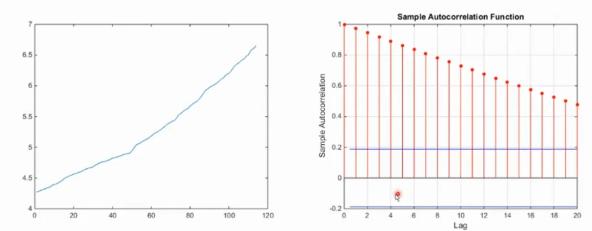

- Neste caso, observamos uma sazonalidade, então não estacionária

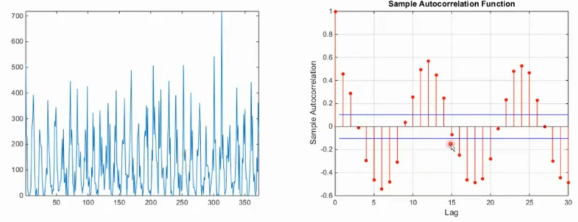

- Em um ruído branco, podemos verificar que a série é estacionária, porém temos variáveis independentes entre si, uma vez que correlação está no intervalo de confiança

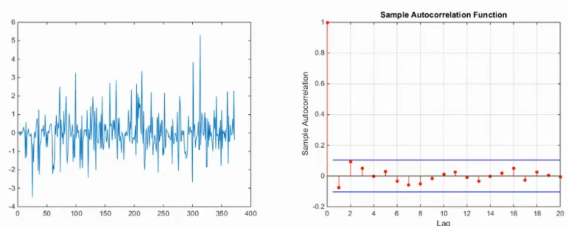

O eixo X, $\text{Lag}$, representa quanto iremos olhar no passado, ou seja, $\text{Lag}_1$ podemos enxergar como se eu estou analisando Fevereiro, então seria como Janeiro tem relação com Fevereiro

In [145]:
import numpy as np
import random
import matplotlib.pyplot as plt
import statsmodels.tsa as tsa 
from statsmodels.graphics.tsaplots import plot_acf

In [146]:
t = np.arange(0, 20, .1)

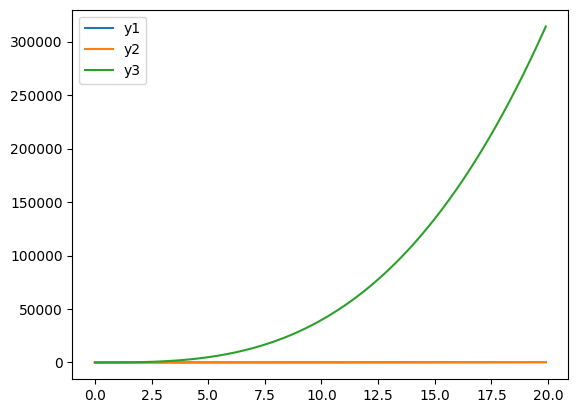

In [147]:
y1 = 10*t + 3
y2 = t**2 + 2*t + 3
y3 = 40*(t**3) - 3*t**2 + 2*t + 3

plt.figure()
plt.plot(t, y1, label='y1')
plt.plot(t, y2, label='y2')
plt.plot(t, y3, label='y3')
plt.legend()
plt.show()

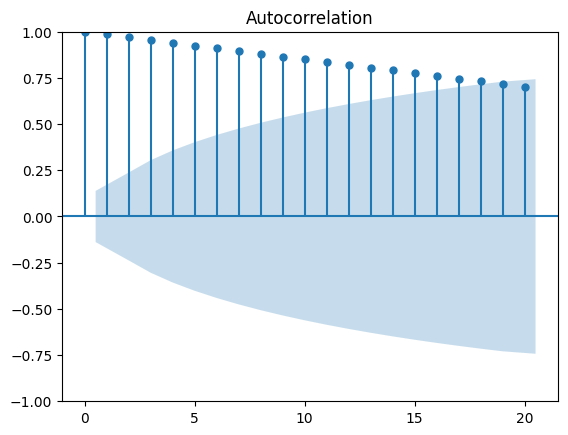

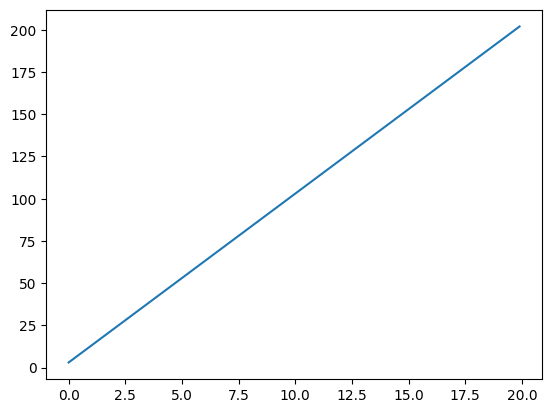

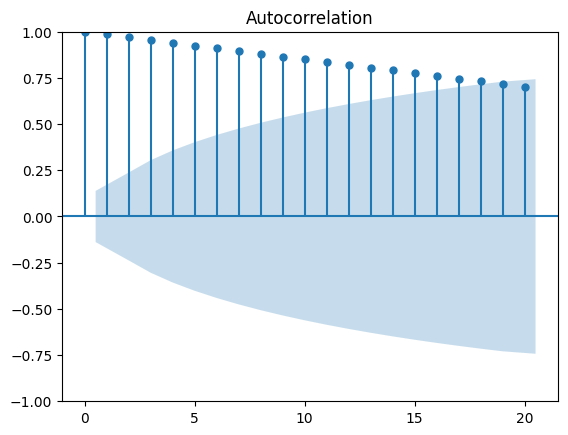

In [148]:
plt.plot(t, y1)


plot_acf(y1, lags=20)

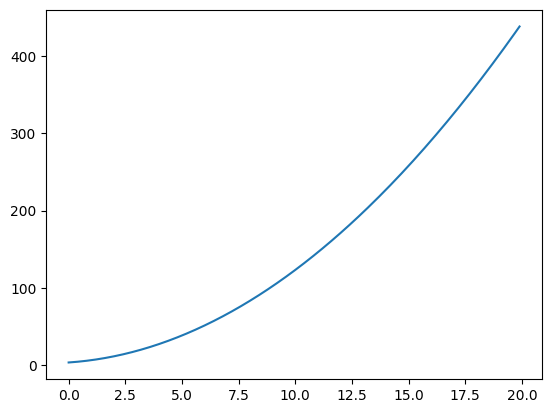

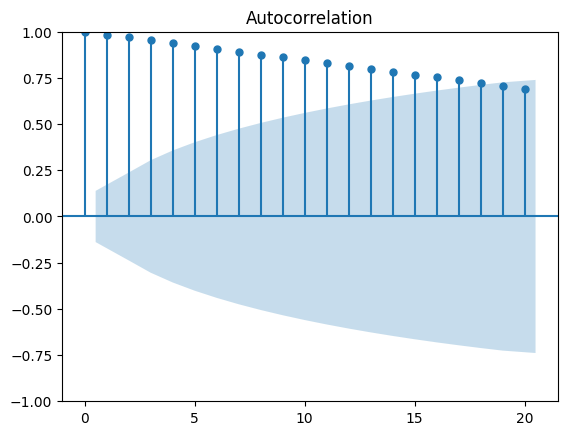

In [149]:
plt.plot(t, y2)


plot_acf(y2, lags=20)
plt.show()

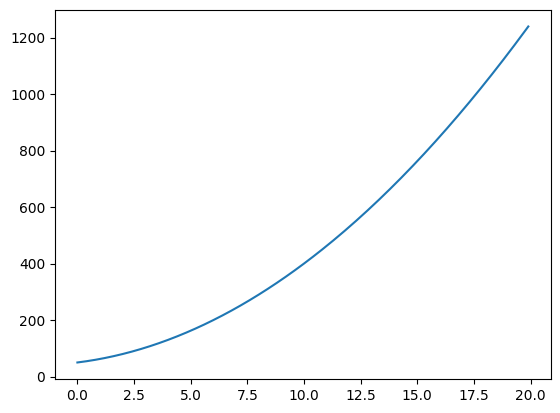

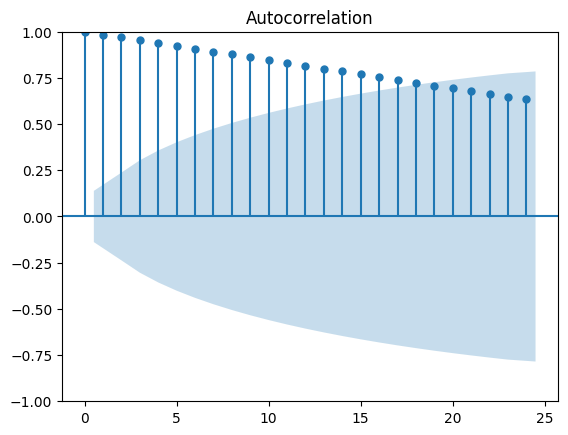

In [150]:
s0, v0,a = 50, 10,5

s = s0 + v0*t + 0.5*(a*t**2)

plt.figure()
plt.plot(t, s)

plot_acf(s)
plt.show()

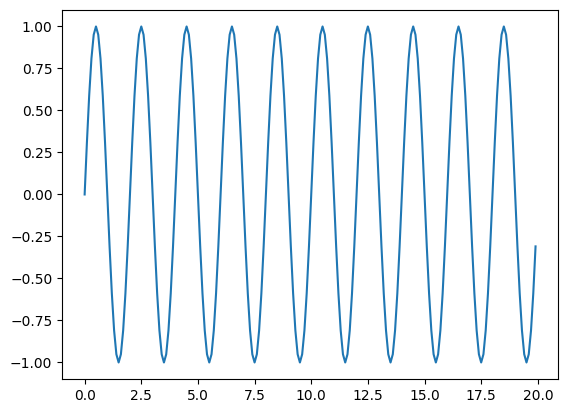

In [151]:
f = 0.01
st = np.sin(np.pi*t)

plt.figure()
plt.plot(t , st)

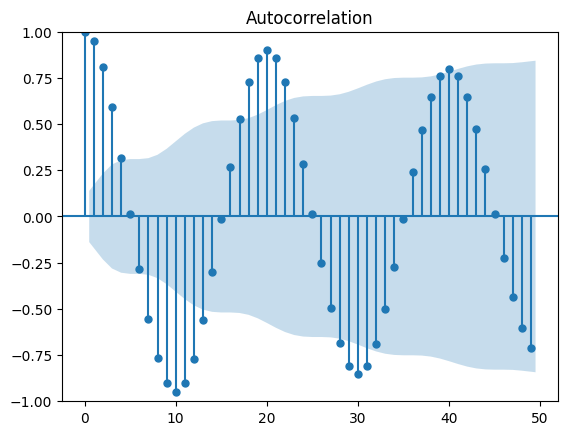

In [152]:
plot_acf(st, lags=49)
plt.show()

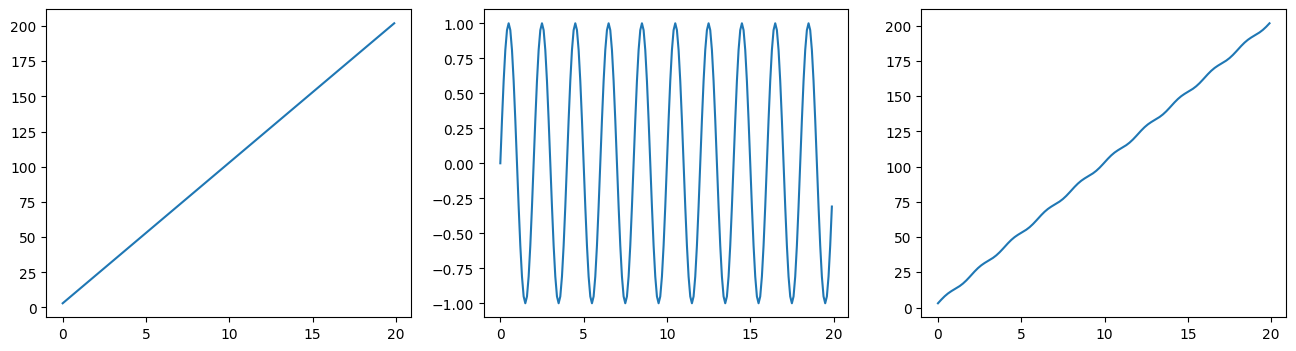

In [153]:
y = st+y1

plt.figure(figsize = (16,4))
plt.subplot(1,3,1)
plt.plot(t, y1)
plt.subplot(1,3,2)
plt.plot(t,st)
plt.subplot(1,3,3)
plt.plot(t, y)

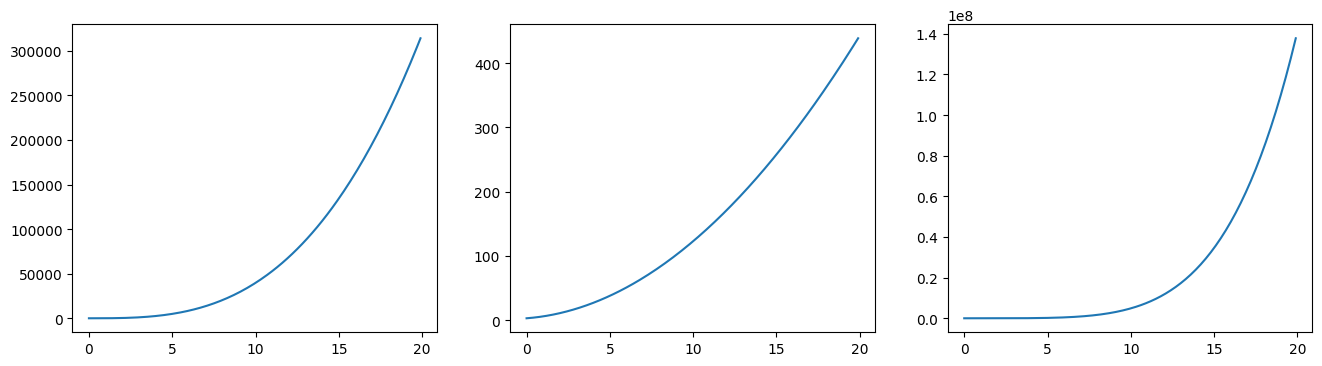

In [154]:
y = y2*y3

plt.figure(figsize = (16,4))
plt.subplot(1,3,1)
plt.plot(t, y3)
plt.subplot(1,3,2)
plt.plot(t,y2)
plt.subplot(1,3,3)
plt.plot(t, y)

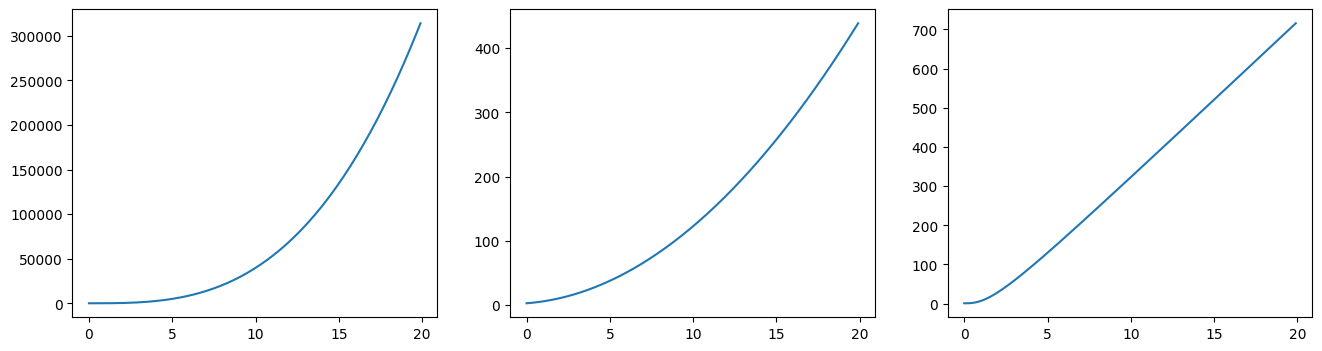

In [155]:
y = y3/y2

plt.figure(figsize = (16,4))
plt.subplot(1,3,1)
plt.plot(t, y3)
plt.subplot(1,3,2)
plt.plot(t,y2)
plt.subplot(1,3,3)
plt.plot(t, y)

### Processos Estocásticos

#### Definição de variáveis pseudo-aleatórias

- Definir x0 (semente)

- Calcular um valor $$ x_n = (a*x_{n-1} + c) * \mod{m}$$

- Após definir o valor de $x_n$, calaremos um valor em uma distribuição uniforme entre (0,1):

$$ U = x_n \div{m}$$

Os valores $a, m, c$ são parâmetros pré-definidos, com os seguintes critérios:
- Para uma semente inicial, a sequência resultante tem a "aparência" deser uma sequência de uniformes independentes

- O número de variáveis que podem ser geradas antes da repetição é muito grande, então o valor de m deve ser grande

- Os valores podem ser calculados eficientemente em um computador

In [156]:
#np.random.seed(1910)

r = random.uniform(0,1)

In [157]:
g = random.gauss(0,1)

### Ruído Branco

É definido como uma sequência de variáveis aleátorias independentes e identicamente distribuídas 

Obs.: Ruído Branco, porque quando capta todas as frequências, no espectro de luz o branco são todas as frequências



In [180]:
u = np.array([np.arange(0, 20, .01)]).T

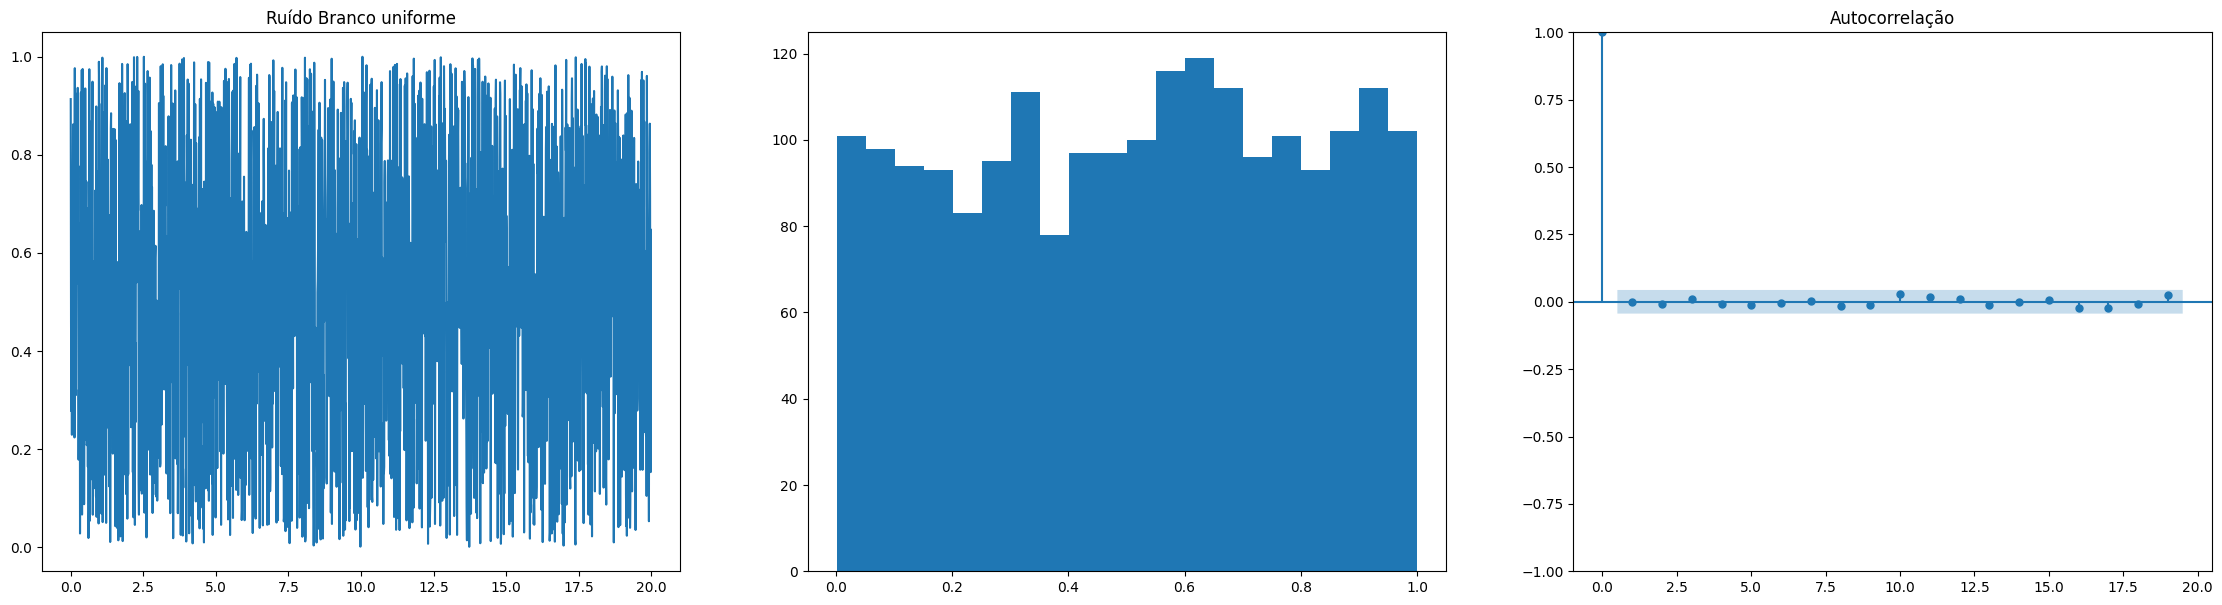

In [181]:
n = len(u)

Ut= np.zeros((n, 1))

for i in range(n):
    Ut[i] = random.uniform(0,1)

plt.figure(figsize=(28,7))

plt.subplot(1,3,1)
plt.plot(u, Ut)
plt.title('Ruído Branco uniforme')

plt.subplot(1,3,2)
plt.hist(Ut, bins=20)

ax3 = plt.subplot(1,3,3)
plot_acf(Ut, lags= 19, title='Autocorrelação', alpha= 0.05, ax=ax3)

plt.show()

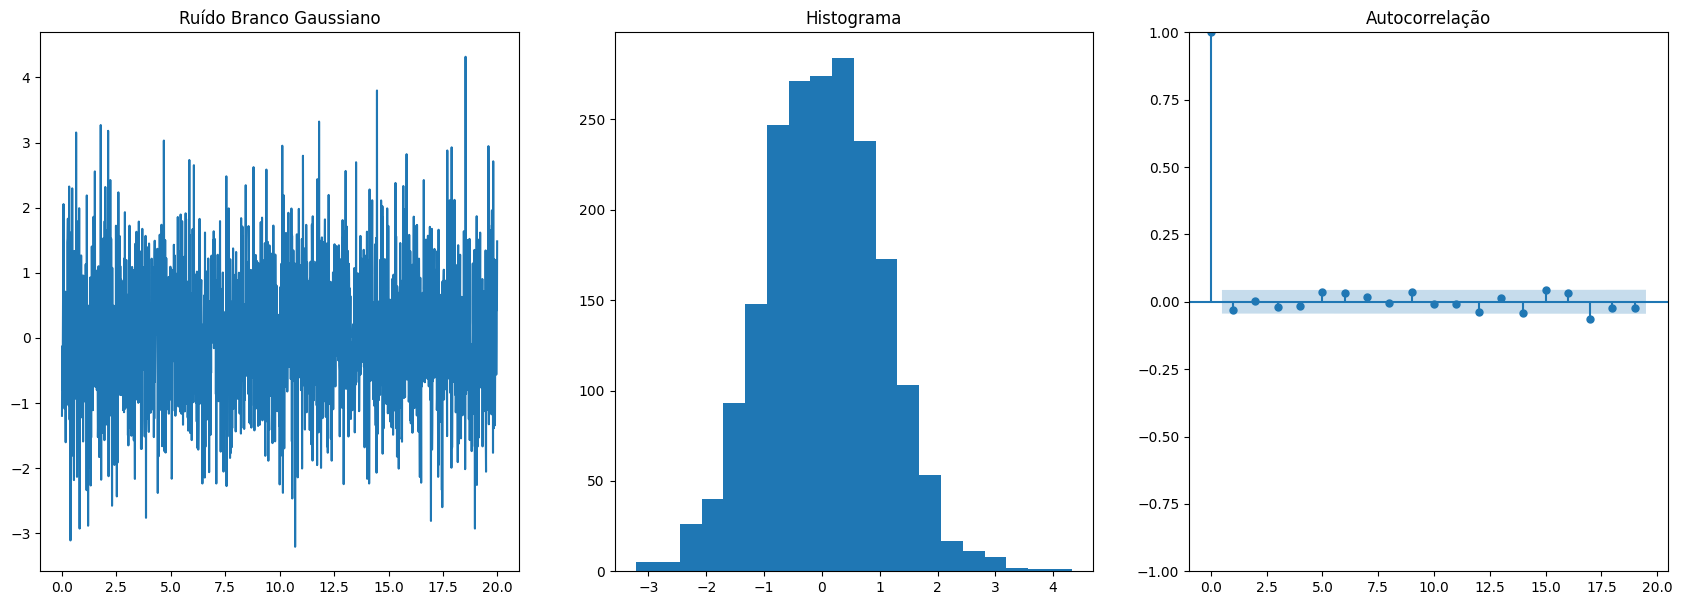

In [214]:
Nt = np.zeros((n,1))

for i in range(n):
    Nt[i] = random.gauss(0, 1)

plt.figure(figsize=(21,7))

plt.subplot(1,3,1)
plt.plot(u, Nt)
plt.title('Ruído Branco Gaussiano')

plt.subplot(1,3,2)
plt.hist(Nt,bins=20)
plt.title('Histograma')

ax3= plt.subplot(1,3,3)
plot_acf(Nt, lags=19, title = 'Autocorrelação', alpha=0.05,ax=ax3)
plt.show()

Text(0.5, 1.0, 'Ruído Branco')

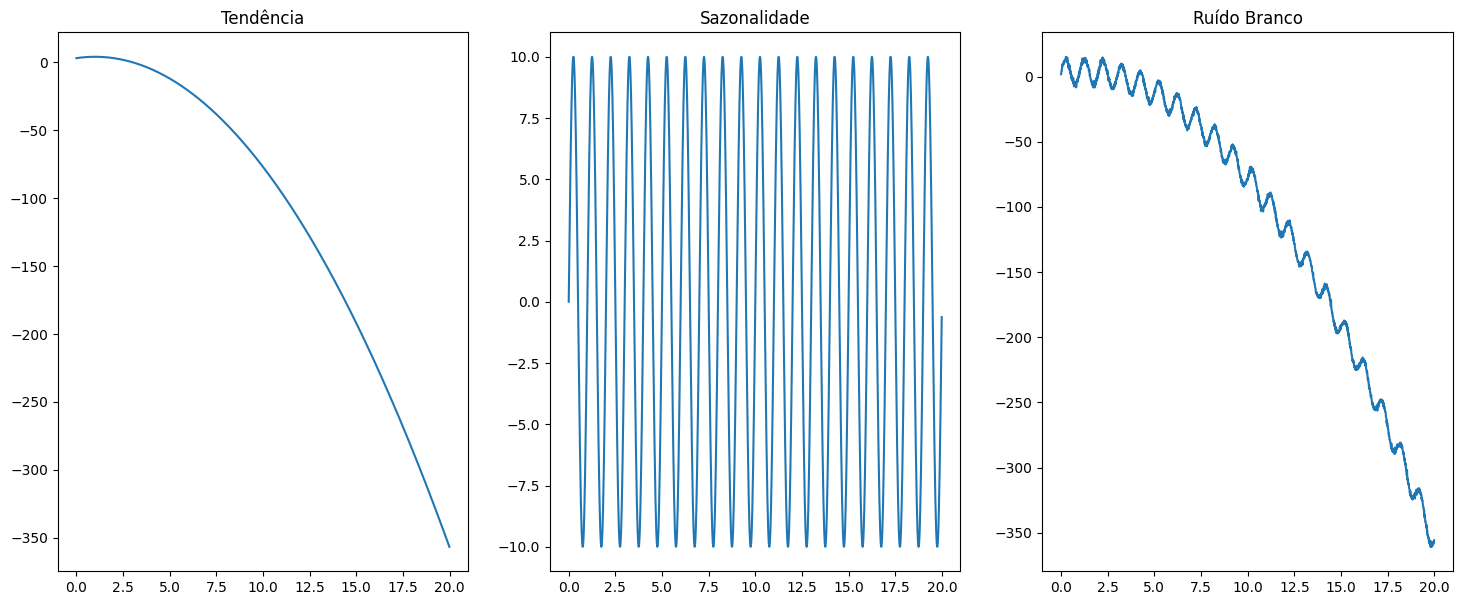

In [220]:
Tt = -t**2 + 2*t + 3

f = 1
st = 10*np.sin(2*np.pi*f*t)
Zt = st+ Tt + Nt

plt.figure(figsize=(18,7))

plt.subplot(1,3,1)
plt.plot(t, Tt)
plt.title('Tendência')

plt.subplot(1,3,2)
plt.plot(t, st)
plt.title('Sazonalidade')

plt.subplot(1,3,3)
plt.plot(t, Zt)
plt.title('Ruído Branco')

### Passeio Aleatório Simples

Para calcular o valor de $Z_t$ (Série Temporal), precisamos calcular como:

$$ Z_t = Z_{t-1} + a_t$$

Desta forma, devemos partir de um estágio inicial, como $Z_0 = 0$, então

$$Z_1 = Z_0 + a_1 => Z_1 = a_1$$

Portanto, a série temporal $Z_n$

$$Z_n = \sum_{t=1}^{n}{a_t}$$


### Processo Autorregressivo AR(1)

- É composto por variáveis independentes e identicamente distribuídas, assim como o passeio aleatório simples, porém o AR difere-se pela possibilidade de ser estacionário, diferentemente do Passeio Aleatório Simples

Fórmula:

$$ Z_t = \phi * Z_{t-1} + a_t$$

Calcular de 1 até n:
$$Z_1 = \phi * Z_0 + a_1 = a_1$$

$$Z_2 = \phi * a_1 + a_2 = \phi * a1 + a2 $$

$$Z_3 = \phi * a_1 + a_2 = \phi * (\phi * a1) + a2 $$


O $\phi$ é responsável por reduzir a importância dos demais ruídos, assim quanto mais antiga é a amostra menos importância terá

### Processo Média-Móveis MA(1)

- É composto por variáveis independentes e identicamente distribuídas, assim como o passeio aleatório simples e AR, porém difere-se do AR por sua função $Z_t$ relacionar os ruídos, ao invés de calcular regressivamente utilizando o $Z_{t-1}$ como base

$$Z_t = a_t - (\theta * a_{t-1})$$

- As MA(1) representam a dependência e importância da amostra obrigatoriamente anterior em 1 $Lag$, ou seja $Z_10$ depende apenas de $Z_9$, além disso Médias Móveis modelam obrigatoriamente o inverso, ou seja, caso $Z_{t-1}$ tenha representado frio, então $Z_t$ representará calor


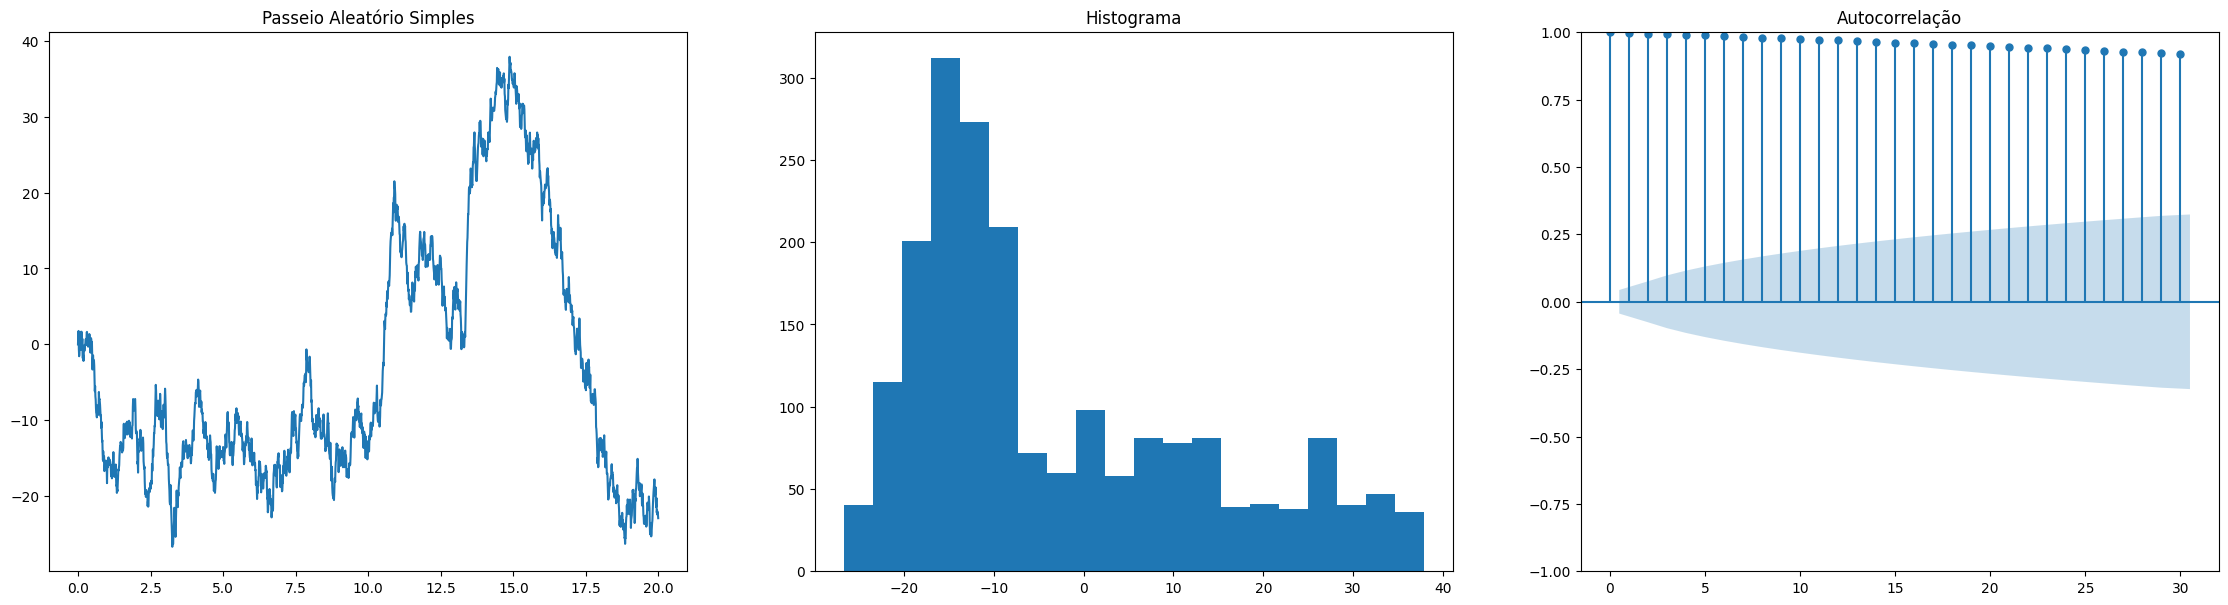

In [255]:
# Passeio Aleatório Simples

ZtPA = np.zeros((n,1))

for i in range(1,n):
    ZtPA [i] = ZtPA[i-1] + random.gauss(0,1)

plt.figure(figsize=(28,7))

plt.subplot(1,3,1)
plt.plot(u, ZtPA)
plt.title('Passeio Aleatório Simples')

plt.subplot(1,3,2)
plt.hist(ZtPA, bins = 20)
plt.title('Histograma')

ax3= plt.subplot(1,3,3)
plot_acf(ZtPA, lags=30, title = 'Autocorrelação', alpha = 0.05, ax=ax3)

plt.show()

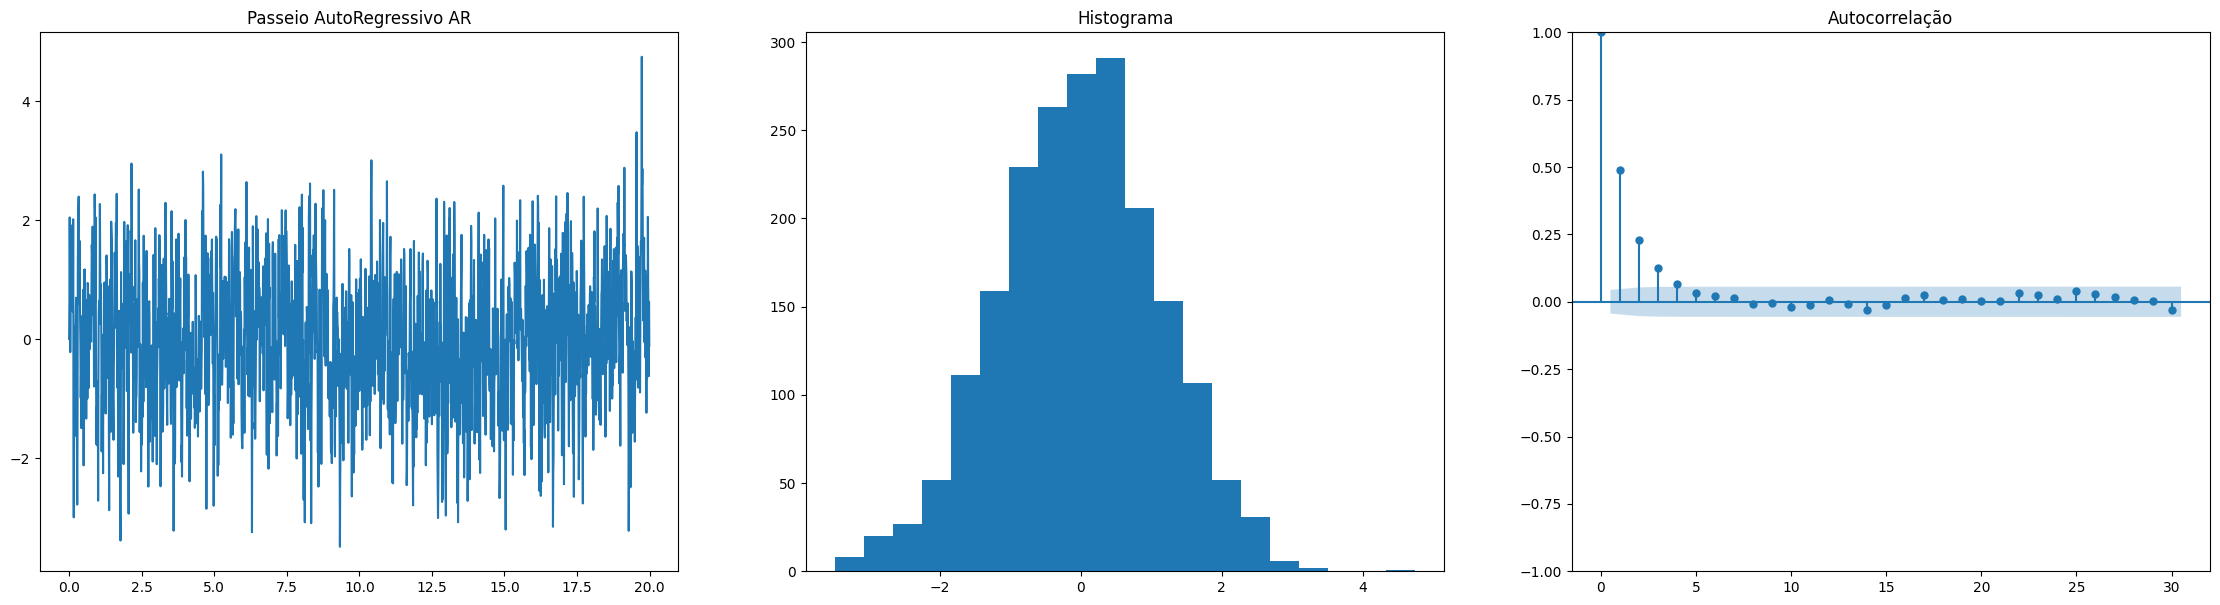

In [ ]:
#Passeio AutoRegressivo AR

ZtAR = np.zeros((n,1))

phi= 0.5

for i in range(1, n):
    ZtAR[i] = (phi * ZtAR[i-1]) + random.gauss(0,1)

plt.figure(figsize=(28,7))

plt.subplot(1,3,1)
plt.plot(u, ZtAR)
plt.title('Passeio AutoRegressivo AR')

plt.subplot(1,3,2)
plt.hist(ZtAR, bins = 20)
plt.title('Histograma')

ax3= plt.subplot(1,3,3)
plot_acf(ZtAR, lags=30, title = 'Autocorrelação', alpha = 0.05, ax=ax3)

plt.show()

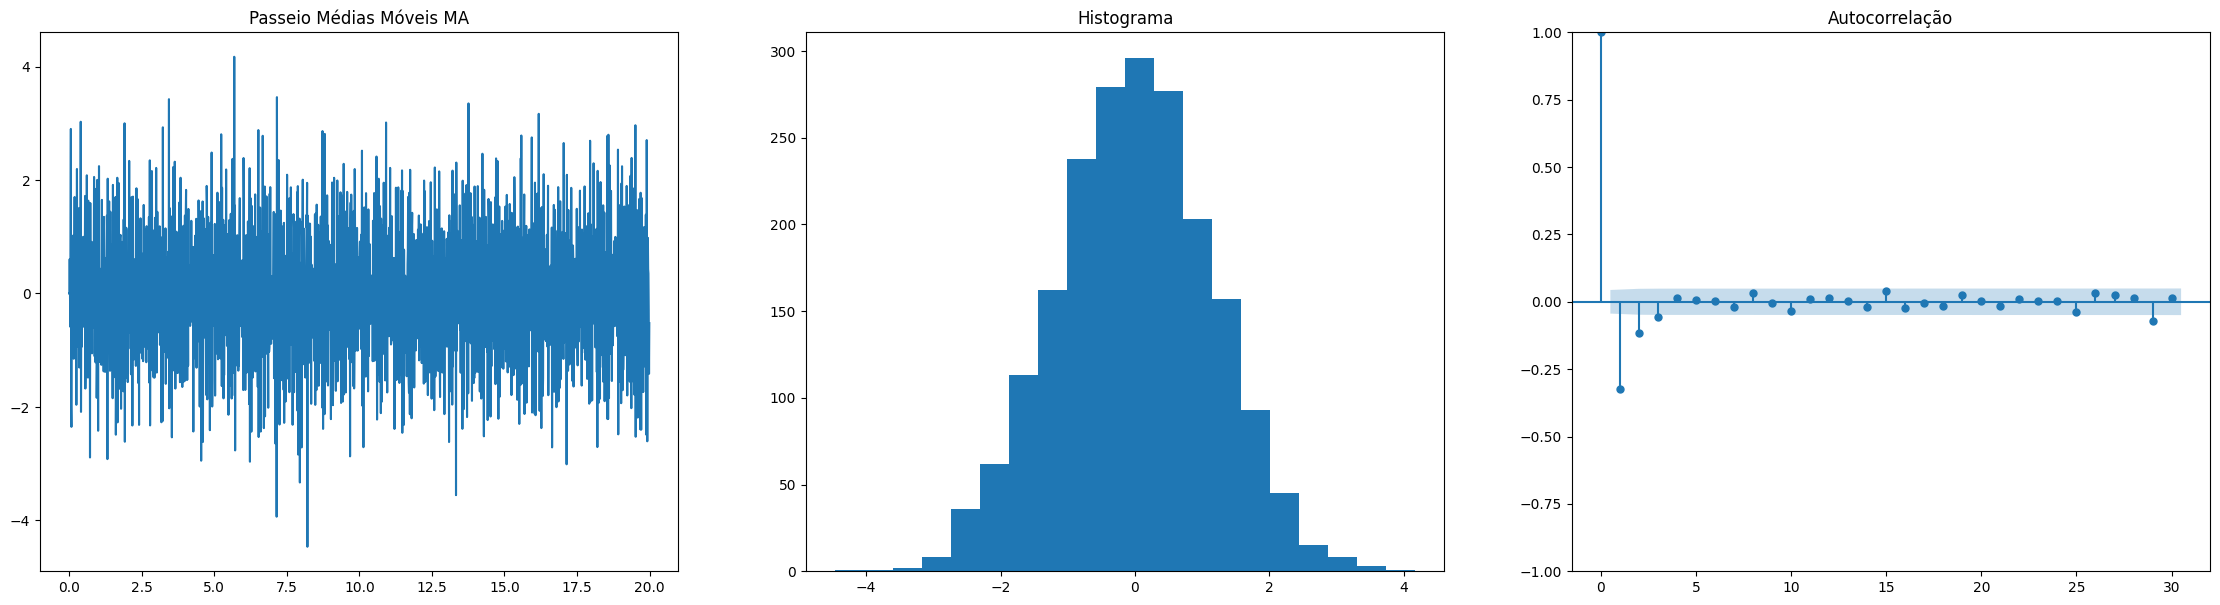

In [266]:
#Passeio Médias Móveis

ZtMA = np.zeros((n,1))

theta1 = 0.5
theta2 = 0.2

at = np.zeros((n,1))

for i in range(n):
    at[i] = + random.gauss(0,1)


for i in range(2, n):
    ZtMA[i] =  at[i] - (theta1 * + at[i-1]) - (theta2 * + at[i-2]) 

plt.figure(figsize=(28,7))

plt.subplot(1,3,1)
plt.plot(u, ZtMA)
plt.title('Passeio Médias Móveis MA')

plt.subplot(1,3,2)
plt.hist(ZtMA, bins = 20)
plt.title('Histograma')

ax3= plt.subplot(1,3,3)
plot_acf(ZtMA, lags=30, title = 'Autocorrelação', alpha = 0.05, ax=ax3)

plt.show()

## Modelos de Decomposição

### Séries com Tendência

### Tendência Constante

Z(t) = T(t) + e(t)

Temos como objetivo obter uma estimativa para T(t) para estimar

Assim, tentamos encontrar:

Y(t) = Z(t) - T'(t)

O valor Y(t) seria uma estimativa do componente estocástico, uma vez que o T'(t) também é uma estimativa do fator determinístico

### Tendência Polinomial

T(t) = B0 + B1*t + B2*t² + ... + Bm*tm

Para uma tendência polinomial, a ordem do polinômio precisa ser bem menor do que a quantidade de amostra

Sistemas Lineares:

- Quando temos uma sistema linear, podemos calcular os valores das variáveis de maneira matricial ou susbtituição, porém para podermos calcular o número de equações do sistema deve ser maior ou igual a quantidade de variáveis do sistema, lembrando que quando criamos mais equações que variáveis diminui o erro numérico